In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [74]:
df = pd.read_csv("cars.csv")

print("Dataset ölçüsü:", df.shape)
display(df.head())

Dataset ölçüsü: (653721, 56)


,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.0,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.6,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.0,AZN,Şəmi,NaN,507687355.0,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.7,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.0,AZN,NaN,Lada Azərbaycan,554092445.0,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.0,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.0,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.0,USD,Anar,NaN,502126242.0,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.0,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.0,AZN,Babək,NaN,774999004.0,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyo

In [75]:
print(df.columns.tolist())

['id_x', 'car_rel_url_x', 'datetime_scrape', 'name', 'price_x', 'currency_x', 'datetime_product', 'city', 'day', 'hour', 'attributes', 'production_year', 'engine_displacement_num', 'engine_displacement_unit', 'kilometrage_num', 'kilometrage_unit', 'barter', 'loan', 'salon', 'spare_parts', 'vip', 'featured', 'img_url', 'id_y', 'cars_id', 'car_rel_url_y', 'datetime', 'description', 'price_y', 'currency_y', 'owner_name', 'shop_name', 'phone', 'updated', 'views', 'vin', 'car_details_id_x', 'Ban növü', 'Buraxılış ili', 'Hansı bazar üçün yığılıb', 'Marka', 'Model', 'Mühərrik', 'Qəzalı', 'Rəng', 'Sahiblər', 'Sürətlər qutusu', 'Vəziyyəti', 'Yeni', 'Yerlərin sayı', 'Yürüş', 'Ötürücü', 'Şəhər', 'car_details_id_y', 'car_rel_url', 'extra_info']


In [76]:
print("price_x məlumat tipi:", df["price_x"].dtype)
print("price_y məlumat tipi:", df["price_y"].dtype)

print("\nprice_x boş dəyərlər:", df["price_x"].isna().sum())
print("price_y boş dəyərlər:", df["price_y"].isna().sum())

price_x məlumat tipi: float64
price_y məlumat tipi: float64

price_x boş dəyərlər: 0
price_y boş dəyərlər: 0


In [77]:
df["price_x"] = pd.to_numeric(df["price_x"], errors="coerce")
df["price_y"] = pd.to_numeric(df["price_y"], errors="coerce")

In [78]:
both_prices = df[
    df["price_x"].notna() & 
    df["price_y"].notna()
].copy()

different_prices = both_prices[
    both_prices["price_x"] != both_prices["price_y"]
]

same_prices = both_prices[
    both_prices["price_x"] == both_prices["price_y"]
]

print("Hər ikisi mövcud:", len(both_prices))
print("Eyni olanlar:", len(same_prices))
print("Fərqli olanlar:", len(different_prices))

display(different_prices[["price_x", "price_y"]].head(20))

Hər ikisi mövcud: 653721
Eyni olanlar: 653422
Fərqli olanlar: 299


,price_x,price_y
1413,18500.0,18000.0
3677,34700.0,35500.0
4604,8300.0,7800.0
7107,28500.0,28000.0
14813,22900.0,22400.0
14844,16500.0,15900.0
21983,24500.0,25500.0
24029,40000.0,38000.0
24234,37000.0,35000.0
24640,8300.0,8500.0


In [79]:
df_analysis = df[
    df["price_x"].notna() & 
    (df["price_x"] > 0)
].copy()

print("Analiz üçün dataset ölçüsü:", df_analysis.shape)

Analiz üçün dataset ölçüsü: (653721, 56)


**CHECKPOINT 1** — Təsviri statistika

In [80]:
print("Ümumi qiymət statistikası:")

display(
    df_analysis["price_x"].describe()
)

Ümumi qiymət statistikası:


count    653721.000000
mean      31630.966437
std       28679.360855
min         500.000000
25%       16800.000000
50%       25300.000000
75%       36800.000000
max      940000.000000
Name: price_x, dtype: float64

In [81]:
gearbox_stats = (
    df_analysis
    .groupby("Sürətlər qutusu")["price_x"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(gearbox_stats)

,count,mean,median,std,min,max
Sürətlər qutusu,,,,,,
Avtomat,469853,34455.898824,27200.0,30774.689705,500.0,940000.0
Mexaniki,95477,17017.773401,12500.0,15577.542749,500.0,370000.0
Reduktor,23143,47561.474053,44000.0,29196.933416,700.0,520000.0
Robot,8261,36999.394383,29500.0,28118.326162,2950.0,345000.0
Variator,56987,25575.068665,22400.0,13851.955006,1100.0,215000.0


In [82]:
new_stats = (
    df_analysis
    .groupby("Yeni")["price_x"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(new_stats)

,count,mean,median,std,min,max
Yeni,,,,,,
Bəli,88562,53472.181161,42500.0,43666.938150,500.0,550000.0
Xeyr,565159,28208.386847,23800.0,23793.468188,500.0,940000.0


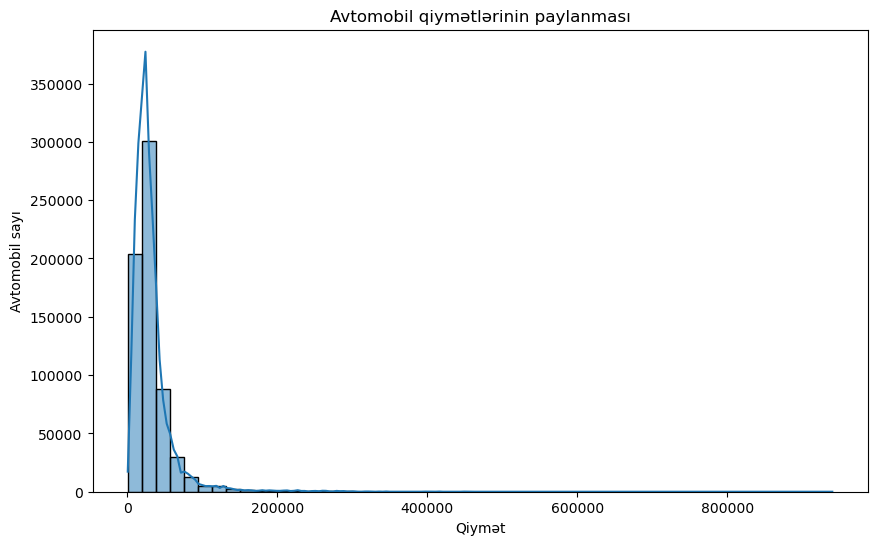

In [83]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_analysis["price_x"],
    bins=50,
    kde=True
)

plt.title("Avtomobil qiymətlərinin paylanması")
plt.xlabel("Qiymət")
plt.ylabel("Avtomobil sayı")

plt.show()

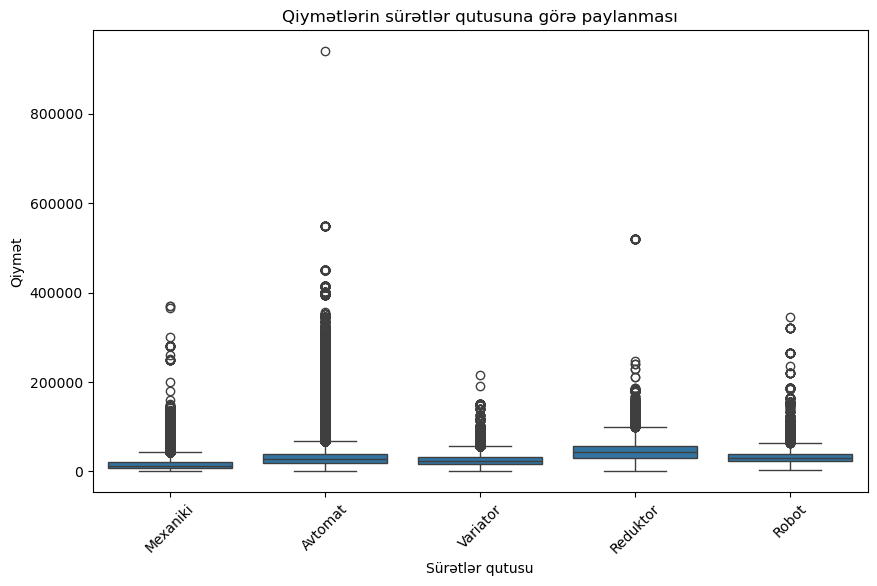

In [84]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_analysis,
    x="Sürətlər qutusu",
    y="price_x"
)

plt.title("Qiymətlərin sürətlər qutusuna görə paylanması")
plt.xlabel("Sürətlər qutusu")
plt.ylabel("Qiymət")

plt.xticks(rotation=45)

plt.show()

**CHECKPOINT 2** — Business Questions və hipotezlər

**Business Question 1**

-Avtomatik və mexaniki avtomobillərin orta qiymətləri arasında statistik əhəmiyyətli fərq varmı?

H0: Avtomatik və mexaniki avtomobillərin orta qiymətləri arasında fərq yoxdur.

H1: Avtomatik və mexaniki avtomobillərin orta qiymətləri arasında fərq var.

Test: Independent Samples t-test

**Business Question 2**

-Avtomobilin yeni/işlənmiş olması ilə qiymət kateqoriyası arasında statistik əhəmiyyətli əlaqə varmı?

H0: Yeni/işlənmiş olması ilə qiymət kateqoriyası arasında əlaqə yoxdur.

H1: Bu dəyişənlər arasında əlaqə var.

Test: Chi-Square Test of Independence

**CHECKPOINT 3** — Statistik testlər və assumption checks

In [85]:
print(
    df_analysis["Sürətlər qutusu"]
    .value_counts(dropna=False)
)

Sürətlər qutusu
Avtomat     469853
Mexaniki     95477
Variator     56987
Reduktor     23143
Robot         8261
Name: count, dtype: int64


In [86]:
automatic = df_analysis.loc[
    df_analysis["Sürətlər qutusu"] == "Avtomat",
    "price_x"
]

manual = df_analysis.loc[
    df_analysis["Sürətlər qutusu"] == "Mexaniki",
    "price_x"
]

print("Avtomatik:", len(automatic))
print("Mexaniki:", len(manual))

Avtomatik: 469853
Mexaniki: 95477


In [87]:
print("Avtomatik orta qiymət:", automatic.mean())
print("Mexaniki orta qiymət:", manual.mean())

Avtomatik orta qiymət: 34455.89882367464
Mexaniki orta qiymət: 17017.773400923783


In [88]:
automatic_sample = automatic.sample(
    min(len(automatic), 5000),
    random_state=42
)

manual_sample = manual.sample(
    min(len(manual), 5000),
    random_state=42
)

shapiro_auto = shapiro(automatic_sample)
shapiro_manual = shapiro(manual_sample)

print("Automatic Shapiro p-value:", shapiro_auto.pvalue)
print("Manual Shapiro p-value:", shapiro_manual.pvalue)

Automatic Shapiro p-value: 1.5499394808130764e-74
Manual Shapiro p-value: 3.086085962230646e-69


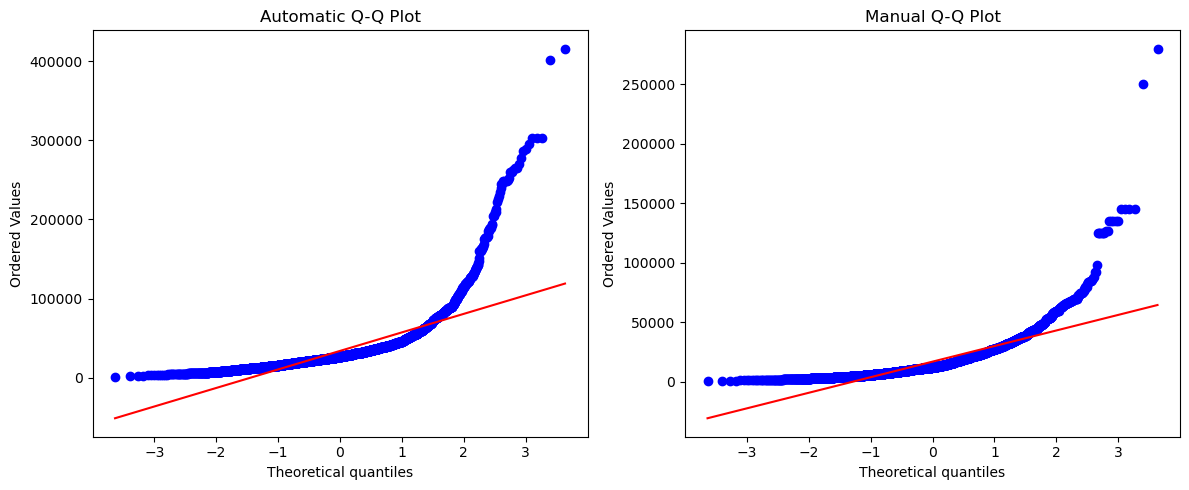

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(
    automatic_sample,
    dist="norm",
    plot=axes[0]
)

axes[0].set_title("Automatic Q-Q Plot")

stats.probplot(
    manual_sample,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Manual Q-Q Plot")

plt.tight_layout()
plt.show()

In [90]:
levene_result = levene(
    automatic,
    manual,
    center="median"
)

print("Levene statistic:", levene_result.statistic)
print("Levene p-value:", levene_result.pvalue)

Levene statistic: 5151.789267671077
Levene p-value: 0.0


In [91]:
t_statistic, p_value_ttest = ttest_ind(
    automatic,
    manual,
    equal_var=False
)

print("T-statistic:", t_statistic)
print("P-value:", p_value_ttest)

T-statistic: 258.31424370785464
P-value: 0.0


In [92]:
n1 = len(automatic)
n2 = len(manual)

mean1 = automatic.mean()
mean2 = manual.mean()

var1 = automatic.var(ddof=1)
var2 = manual.var(ddof=1)

mean_difference = mean1 - mean2

standard_error = np.sqrt(
    var1 / n1 + var2 / n2
)

welch_df = (
    (var1 / n1 + var2 / n2) ** 2
    /
    (
        ((var1 / n1) ** 2) / (n1 - 1)
        +
        ((var2 / n2) ** 2) / (n2 - 1)
    )
)

critical_value = stats.t.ppf(
    0.975,
    welch_df
)

margin_of_error = critical_value * standard_error

ci_lower = mean_difference - margin_of_error
ci_upper = mean_difference + margin_of_error

print("Mean difference:", mean_difference)
print("95% CI lower:", ci_lower)
print("95% CI upper:", ci_upper)

Mean difference: 17438.125422750854
95% CI lower: 17305.812743118673
95% CI upper: 17570.438102383036


In [93]:
df_analysis["price_category"] = pd.qcut(
    df_analysis["price_x"],
    q=3,
    labels=["Low", "Medium", "High"]
)
print(df_analysis["price_category"].value_counts())

price_category
Medium    222229
Low       217945
High      213547
Name: count, dtype: int64


CHECKPOINT 4 — Chi-Square Test

In [94]:
print("=== T-TEST NƏTİCƏLƏRİ ===")

print(f"Avtomatik orta qiymət: {mean1:.2f}")
print(f"Mexaniki orta qiymət: {mean2:.2f}")

print(f"\nOrta qiymət fərqi (Automatic - Manual): {mean_difference:.2f}")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value_ttest:.6f}")

print(f"\n95% Confidence Interval:")
print(f"Lower bound: {ci_lower:.2f}")
print(f"Upper bound: {ci_upper:.2f}")

=== T-TEST NƏTİCƏLƏRİ ===
Avtomatik orta qiymət: 34455.90
Mexaniki orta qiymət: 17017.77

Orta qiymət fərqi (Automatic - Manual): 17438.13
T-statistic: 258.3142
P-value: 0.000000

95% Confidence Interval:
Lower bound: 17305.81
Upper bound: 17570.44


In [95]:
print("=== P-VALUE INTERPRETATION ===")

if p_value_ttest < 0.05:
    print(
        f"P-value = {p_value_ttest:.6f}. "
        "Bu nəticə H0 doğru olduğu halda müşahidə etdiyimiz "
        "fərq qədər və ya ondan daha ekstremal fərqin alınmasının "
        "çox az ehtimal olunan olduğunu göstərir."
    )
    print(
        "Bu səbəbdən H0 rədd edilir və avtomatik və mexaniki "
        "avtomobillərin orta qiymətləri arasında statistik "
        "əhəmiyyətli fərq olduğuna dair sübut var."
    )
else:
    print(
        f"P-value = {p_value_ttest:.6f}. "
        "Bu nəticə H0 doğru olduğu halda müşahidə etdiyimiz "
        "fərq qədər və ya daha ekstremal nəticənin qeyri-adi "
        "olmadığını göstərir."
    )
    print(
        "Bu səbəbdən H0 rədd edilmir və avtomatik və mexaniki "
        "avtomobillərin orta qiymətləri arasında statistik "
        "əhəmiyyətli fərq olduğunu göstərmək üçün kifayət qədər "
        "sübut yoxdur."
    )

=== P-VALUE INTERPRETATION ===
P-value = 0.000000. Bu nəticə H0 doğru olduğu halda müşahidə etdiyimiz fərq qədər və ya ondan daha ekstremal fərqin alınmasının çox az ehtimal olunan olduğunu göstərir.
Bu səbəbdən H0 rədd edilir və avtomatik və mexaniki avtomobillərin orta qiymətləri arasında statistik əhəmiyyətli fərq olduğuna dair sübut var.


In [96]:
print("=== 95% CONFIDENCE INTERVAL INTERPRETATION ===")

print(
    f"Orta qiymət fərqi: {mean_difference:.2f}"
)

print(
    f"95% Confidence Interval: "
    f"({ci_lower:.2f}, {ci_upper:.2f})"
)

if ci_lower > 0:
    print(
        "\n95% confidence interval tamamilə müsbətdir. "
        "Bu, avtomatik avtomobillərin orta qiymətinin "
        "mexaniki avtomobillərdən daha yüksək olması ilə "
        "uyğundur."
    )
elif ci_upper < 0:
    print(
        "\n95% confidence interval tamamilə mənfidir. "
        "Bu, avtomatik avtomobillərin orta qiymətinin "
        "mexaniki avtomobillərdən daha aşağı olması ilə "
        "uyğundur."
    )
else:
    print(
        "\n95% confidence interval 0-ı əhatə edir. "
        "Bu, iki qrupun orta qiymətləri arasında fərqin "
        "statistik olaraq əhəmiyyətli olmaması ilə uyğundur."
    )

=== 95% CONFIDENCE INTERVAL INTERPRETATION ===
Orta qiymət fərqi: 17438.13
95% Confidence Interval: (17305.81, 17570.44)

95% confidence interval tamamilə müsbətdir. Bu, avtomatik avtomobillərin orta qiymətinin mexaniki avtomobillərdən daha yüksək olması ilə uyğundur.


In [97]:
print("=== STATISTICAL AND BUSINESS INTERPRETATION ===")

print(f"Orta qiymət fərqi: {mean_difference:.2f} AZN")
print(f"P-value: {p_value_ttest:.6f}")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")

if p_value_ttest < 0.05:
    print(
        "\nStatistik baxımdan fərq əhəmiyyətlidir."
    )
    
    if mean_difference > 0:
        print(
            f"Orta hesabla avtomatik avtomobillərin qiyməti "
            f"mexaniki avtomobillərdən təxminən "
            f"{mean_difference:.2f} AZN yüksəkdir."
        )
    else:
        print(
            f"Orta hesabla avtomatik avtomobillərin qiyməti "
            f"mexaniki avtomobillərdən təxminən "
            f"{abs(mean_difference):.2f} AZN aşağıdır."
        )
else:
    print(
        "\nStatistik baxımdan əhəmiyyətli fərq aşkar edilmədi."
    )
    
    print(
        "Bu nəticə iki qrup arasında heç bir fərqin mütləq "
        "olmadığını sübut etmir; sadəcə mövcud data ilə "
        "fərqin statistik əhəmiyyətli olduğunu göstərmək "
        "üçün kifayət qədər sübut yoxdur."
    )

=== STATISTICAL AND BUSINESS INTERPRETATION ===
Orta qiymət fərqi: 17438.13 AZN
P-value: 0.000000
95% CI: (17305.81, 17570.44)

Statistik baxımdan fərq əhəmiyyətlidir.
Orta hesabla avtomatik avtomobillərin qiyməti mexaniki avtomobillərdən təxminən 17438.13 AZN yüksəkdir.


In [98]:
chi_df = df_analysis[
    df_analysis["Yeni"].notna() &
    df_analysis["price_category"].notna()
].copy()

contingency_table = pd.crosstab(
    chi_df["Yeni"],
    chi_df["price_category"]
)

display(contingency_table)

price_category,Low,Medium,High
Yeni,,,
Bəli,9067,18030,61465
Xeyr,208878,204199,152082


In [99]:
print("=== CHI-SQUARE P-VALUE INTERPRETATION ===")
chi2_statistic, p_value_chi, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2_statistic)
print("P-value:", p_value_chi)
print("Degrees of freedom:", degrees_of_freedom)
print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"P-value: {p_value_chi:.6f}")
print(f"Degrees of freedom: {degrees_of_freedom}")

if p_value_chi < 0.05:
    print(
        "\nP-value 0.05-dən kiçikdir. "
        "Yeni/işlənmiş avtomobil statusu ilə qiymət kateqoriyası "
        "arasında əlaqənin olmadığını ifadə edən H0 altında "
        "müşahidə olunan əlaqənin bu qədər güclü olması "
        "çox az ehtimallıdır."
    )
    
    print(
        "Buna görə H0 rədd edilir və iki dəyişən arasında "
        "statistik əhəmiyyətli əlaqə olduğuna dair sübut var."
    )
else:
    print(
        "\nP-value 0.05-dən böyük və ya bərabərdir. "
        "H0 doğru olduqda müşahidə olunan əlaqə qeyri-adi "
        "hesab edilmir."
    )
    
    print(
        "Buna görə H0 rədd edilmir və iki dəyişən arasında "
        "statistik əhəmiyyətli əlaqə olduğunu göstərmək "
        "üçün kifayət qədər sübut yoxdur."
    )

=== CHI-SQUARE P-VALUE INTERPRETATION ===
Chi-square statistic: 64323.53531896818
P-value: 0.0
Degrees of freedom: 2
Chi-square statistic: 64323.5353
P-value: 0.000000
Degrees of freedom: 2

P-value 0.05-dən kiçikdir. Yeni/işlənmiş avtomobil statusu ilə qiymət kateqoriyası arasında əlaqənin olmadığını ifadə edən H0 altında müşahidə olunan əlaqənin bu qədər güclü olması çox az ehtimallıdır.
Buna görə H0 rədd edilir və iki dəyişən arasında statistik əhəmiyyətli əlaqə olduğuna dair sübut var.


Avtomatik və mexaniki avtomobillərin orta qiymətləri arasındakı fərq üçün 95% confidence interval 17,305.81–17,570.44 AZN təşkil edir. Intervalın tamamilə müsbət olması avtomatik avtomobillərin orta qiymətinin mexaniki avtomobillərdən daha yüksək olması ilə uyğundur. Nümunədə orta qiymət fərqi təxminən 17,438 AZN olmuşdur.

**CHECKPOINT 5** — Parametrik testdən əvvəl fərziyyələrin yoxlanması

In [100]:
automatic = df_analysis.loc[
    df_analysis["Sürətlər qutusu"] == "Avtomat",
    "price_x"
].dropna()

manual = df_analysis.loc[
    df_analysis["Sürətlər qutusu"] == "Mexaniki",
    "price_x"
].dropna()

print("Avtomatik:", len(automatic))
print("Mexaniki:", len(manual))

Avtomatik: 469853
Mexaniki: 95477


In [101]:
print("=== SHAPIRO-WILK NORMALITY TEST ===")

# Shapiro-Wilk böyük datasetlərdə çox həssas ola bilər,
# ona görə maksimum 5000 müşahidə götürürük.
automatic_sample = automatic.sample(
    min(len(automatic), 5000),
    random_state=42
)

manual_sample = manual.sample(
    min(len(manual), 5000),
    random_state=42
)

shapiro_auto = stats.shapiro(automatic_sample)
shapiro_manual = stats.shapiro(manual_sample)

print(f"Automatic p-value: {shapiro_auto.pvalue:.6f}")
print(f"Manual p-value: {shapiro_manual.pvalue:.6f}")

=== SHAPIRO-WILK NORMALITY TEST ===
Automatic p-value: 0.000000
Manual p-value: 0.000000


Shapiro-Wilk testi nəticəsində həm avtomatik, həm də mexaniki avtomobillər üçün p-value 0.05-dən kiçik olmuşdur (p < 0.001). Buna görə normal paylanmanı ifadə edən H0 rədd edilir. Nəticə göstərir ki, hər iki qrupun qiymətləri normal paylanmır.

In [102]:
print("=== LEVENE TEST ===")

levene_result = stats.levene(
    automatic,
    manual,
    center="median"
)

print(f"Levene statistic: {levene_result.statistic:.4f}")
print(f"Levene p-value: {levene_result.pvalue:.6f}")

=== LEVENE TEST ===
Levene statistic: 5151.7893
Levene p-value: 0.000000


T-testdən əvvəl normallıq Shapiro-Wilk testi və Q-Q plot vasitəsilə yoxlanılmışdır. Shapiro-Wilk testində həm avtomatik, həm də mexaniki avtomobillər üçün p-value 0.05-dən kiçik olmuşdur. Buna görə normal paylanmanı ifadə edən H0 rədd edilmiş və qiymətlərin normal paylanmadığı müəyyən edilmişdir.

Dispersiyaların bərabərliyi Levene testi ilə yoxlanılmışdır. Levene testinin p-value-si 0.05-dən kiçik olmuşdur və buna görə dispersiyaların bərabər olduğunu ifadə edən H0 rədd edilmişdir.

Bu nəticələrə əsasən qrupların dispersiyaları bərabər deyil. Buna görə Welch t-testindən istifadə edilməsi daha uyğundur, çünki Welch t-testi bərabər dispersiya fərziyyəsini tələb etmir.

**CHECKPOINT 6** — Statistik nəticəni biznes qərarına bağlayan yazılı nəticə

Aparılan statistik analiz nəticəsində avtomobilin qiyməti ilə bəzi əsas xüsusiyyətlər arasında statistik əhəmiyyətli fərqlər və əlaqələr müəyyən edilmişdir.

İlk biznes sualına əsasən, avtomatik və mexaniki sürətlər qutusuna malik avtomobillərin orta qiymətləri arasında statistik əhəmiyyətli fərq aşkar edilmişdir. Avtomatik avtomobillərin orta qiyməti mexaniki avtomobillərdən təxminən 17,438 AZN daha yüksək olmuşdur. 95% confidence interval 17,305.81–17,570.44 AZN təşkil etmişdir.

İkinci biznes sualında isə avtomobilin yeni və ya işlənmiş olması ilə qiymət kateqoriyası arasında statistik əhəmiyyətli əlaqə müəyyən edilmişdir (χ² = 64323.5353, p < 0.05).

Biznes baxımından, avtomobil qiymətlərinin müəyyənləşdirilməsi zamanı sürətlər qutusu və avtomobilin yeni/işlənmiş olması kimi xüsusiyyətlərin nəzərə alınması məqsədəuyğundur. Bu xüsusiyyətlər qiymət seqmentlərinin formalaşdırılması, avtomobillərin düzgün qiymətləndirilməsi və satış strategiyasının hazırlanmasına kömək edə bilər.

Bununla belə, statistik əlaqə səbəb-nəticə əlaqəsi demək deyil. Qiymətə digər xüsusiyyətlər, məsələn, marka, model, buraxılış ili, yürüş və mühərrik göstəriciləri də təsir edə bilər.